# Post 003 — Tree-Based Learning: Wafer Edge Yield Drop-off

**AI Engineering Lab Series | Post-Silicon Validation Domain**

## The Problem

In semiconductor manufacturing, a silicon wafer is a circular disc from which hundreds of individual chips (dies) are cut. A well-known phenomenon is **edge yield drop-off**: dies near the edge of the wafer fail at a much higher rate than dies near the center.

The reasons are physical: the lithography machine focuses less precisely at the edges, the spin-coated photoresist is thinner near the edge due to centrifugal forces, and the etch gas flow is less uniform near the wafer boundary. The relationship between distance from center and yield is **non-linear** — yield is stable from 0 to ~120mm, then drops sharply.

This non-linear, multi-condition relationship is exactly what **Random Forests** are designed to capture.

## Dataset

| Feature | Description | Units |
|---|---|---|
| `distance_from_center_mm` | Radial distance of the die from wafer center | mm |
| `angle_degrees` | Angular position on the wafer | degrees |
| `etch_gas_flow` | Gas flow rate during etch step | sccm |
| `spin_coat_rpm` | Spin speed during photoresist coating | RPM |
| `litho_overlay_error_nm` | Misalignment between lithography layers | nm |
| `yield_pass` | **Target**: 1 = Pass, 0 = Fail | — |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv('../data/wafer_edge_yield.csv')
print(f'Dataset shape: {df.shape}')
print(f'Pass rate: {df["yield_pass"].mean():.1%}')
df.head()

Dataset shape: (10000, 6)
Pass rate: 90.0%


,distance_from_center_mm,angle_degrees,etch_gas_flow,spin_coat_rpm,litho_overlay_error_nm,yield_pass
0,75.90,347.04,57.70,1928,1.471,1
1,84.76,87.05,49.90,1904,0.538,1
2,76.79,62.38,50.14,2111,1.679,1
3,145.83,304.68,56.52,2086,1.383,0
4,92.24,100.23,43.08,2073,0.623,1


## 1. Wafer Map Visualization

The most important visualization for wafer yield data is the **wafer map** — a 2D scatter plot of die positions colored by pass/fail. This immediately shows the spatial pattern of failures.

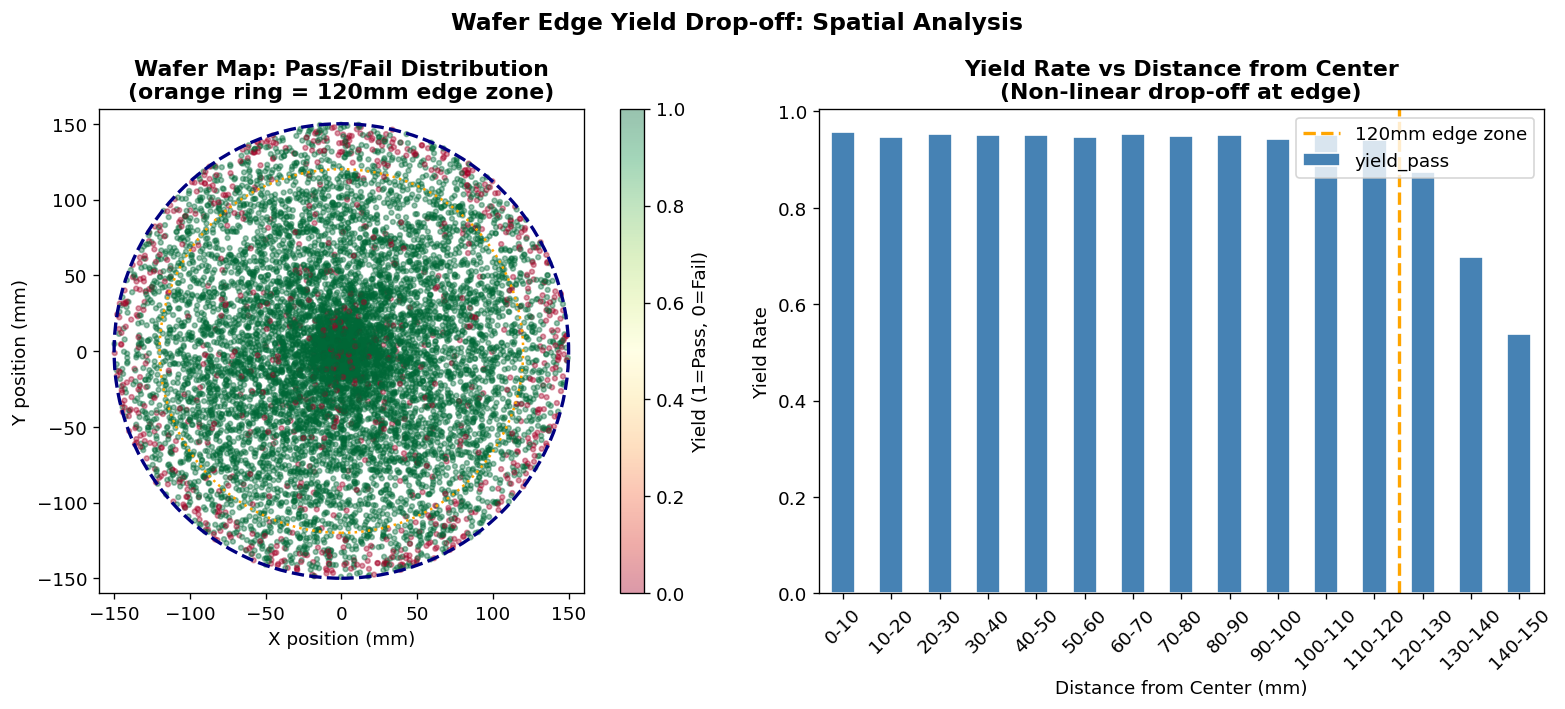

In [2]:
# Convert polar coordinates to Cartesian for wafer map
df['x_mm'] = df['distance_from_center_mm'] * np.cos(np.radians(df['angle_degrees']))
df['y_mm'] = df['distance_from_center_mm'] * np.sin(np.radians(df['angle_degrees']))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full wafer map
ax = axes[0]
scatter = ax.scatter(df['x_mm'], df['y_mm'], c=df['yield_pass'],
                     cmap='RdYlGn', alpha=0.4, s=8)
plt.colorbar(scatter, ax=ax, label='Yield (1=Pass, 0=Fail)')
circle = plt.Circle((0, 0), 150, fill=False, color='navy', linewidth=2, linestyle='--')
ax.add_patch(circle)
circle2 = plt.Circle((0, 0), 120, fill=False, color='orange', linewidth=1.5, linestyle=':')
ax.add_patch(circle2)
ax.set_xlim(-160, 160); ax.set_ylim(-160, 160)
ax.set_aspect('equal')
ax.set_title('Wafer Map: Pass/Fail Distribution\n(orange ring = 120mm edge zone)', fontweight='bold')
ax.set_xlabel('X position (mm)'); ax.set_ylabel('Y position (mm)')

# Yield vs distance
ax = axes[1]
bins = np.arange(0, 155, 10)
df['dist_bin'] = pd.cut(df['distance_from_center_mm'], bins=bins)
yield_by_dist = df.groupby('dist_bin', observed=True)['yield_pass'].mean()
yield_by_dist.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(x=11.5, color='orange', linestyle='--', linewidth=2, label='120mm edge zone')
ax.set_xlabel('Distance from Center (mm)')
ax.set_ylabel('Yield Rate')
ax.set_title('Yield Rate vs Distance from Center\n(Non-linear drop-off at edge)', fontweight='bold')
ax.set_xticklabels([f'{int(b.left)}-{int(b.right)}' for b in yield_by_dist.index], rotation=45)
ax.legend()

plt.suptitle('Wafer Edge Yield Drop-off: Spatial Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/wafer_map_analysis.png', bbox_inches='tight')
plt.show()

## 2. Model Training and Comparison

In [3]:
features = ['distance_from_center_mm', 'angle_degrees', 'etch_gas_flow',
            'spin_coat_rpm', 'litho_overlay_error_nm']
X = df[features]
y = df['yield_pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                             class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10,
                             class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

for name, model in [('Decision Tree', dt), ('Random Forest', rf)]:
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))
    print(f'ROC-AUC: {auc:.3f}')


=== Decision Tree ===
              precision    recall  f1-score   support

        Fail       0.32      0.57      0.41       201
        Pass       0.95      0.87      0.91      1799

    accuracy                           0.84      2000
   macro avg       0.64      0.72      0.66      2000
weighted avg       0.89      0.84      0.86      2000

ROC-AUC: 0.757

=== Random Forest ===
              precision    recall  f1-score   support

        Fail       0.40      0.56      0.47       201
        Pass       0.95      0.91      0.93      1799

    accuracy                           0.87      2000
   macro avg       0.68      0.73      0.70      2000
weighted avg       0.89      0.87      0.88      2000

ROC-AUC: 0.769


## 3. Feature Importance: What Drives Wafer Yield?

The Random Forest's feature importance tells us which process parameters most strongly predict yield. This is directly actionable: the most important features are the ones where process engineers should focus their control efforts.

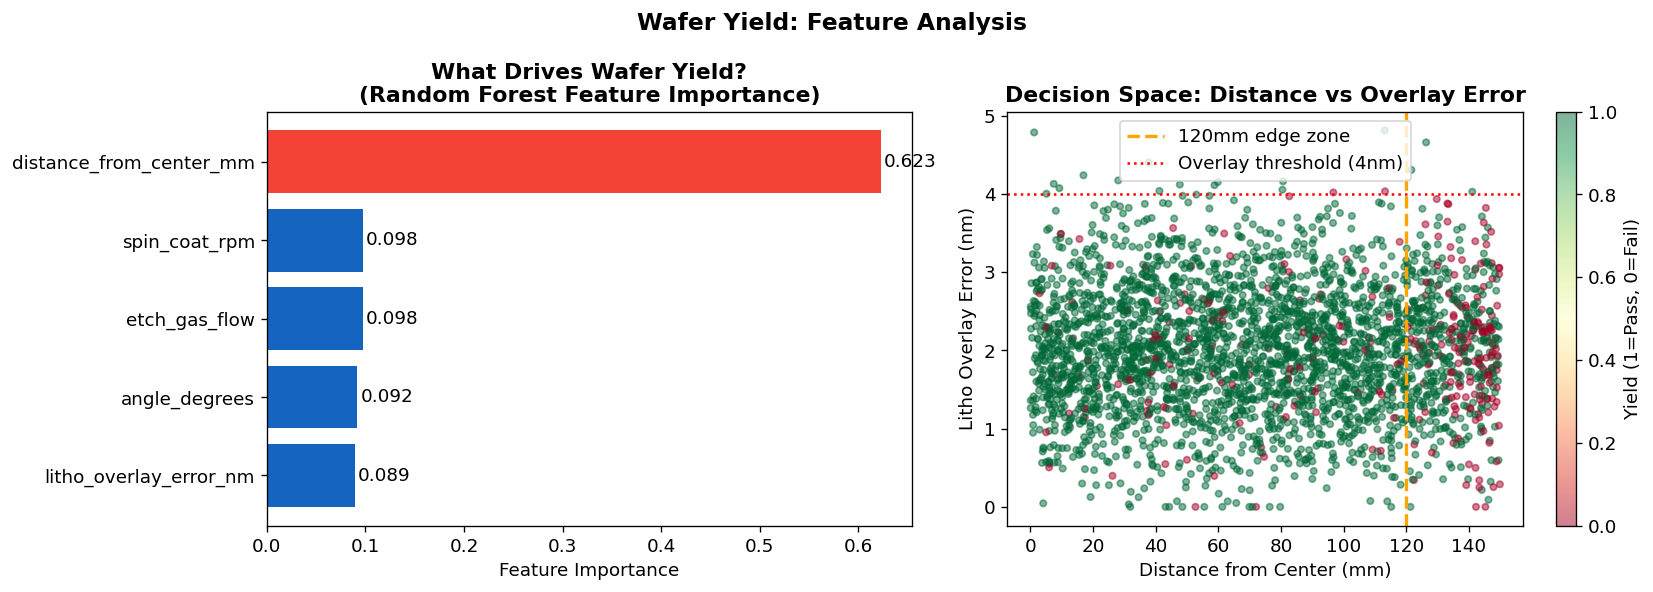

In [4]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
ax = axes[0]
colors = ['#F44336' if v == importances.max() else '#1565C0' for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('What Drives Wafer Yield?\n(Random Forest Feature Importance)', fontweight='bold')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Decision boundary: distance vs overlay error
ax = axes[1]
sample = df.sample(3000, random_state=42)
scatter = ax.scatter(sample['distance_from_center_mm'], sample['litho_overlay_error_nm'],
                     c=sample['yield_pass'], cmap='RdYlGn', alpha=0.5, s=15)
plt.colorbar(scatter, ax=ax, label='Yield (1=Pass, 0=Fail)')
ax.axvline(x=120, color='orange', linestyle='--', linewidth=2, label='120mm edge zone')
ax.axhline(y=4, color='red', linestyle=':', linewidth=1.5, label='Overlay threshold (4nm)')
ax.set_xlabel('Distance from Center (mm)')
ax.set_ylabel('Litho Overlay Error (nm)')
ax.set_title('Decision Space: Distance vs Overlay Error', fontweight='bold')
ax.legend()

plt.suptitle('Wafer Yield: Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/wafer_feature_analysis.png', bbox_inches='tight')
plt.show()

## 4. Predicted Yield Map

The most powerful validation of our model is to compare the **actual wafer map** with the **model's predicted yield map**. If the model has learned the edge drop-off pattern, the predicted map should look like the actual map.

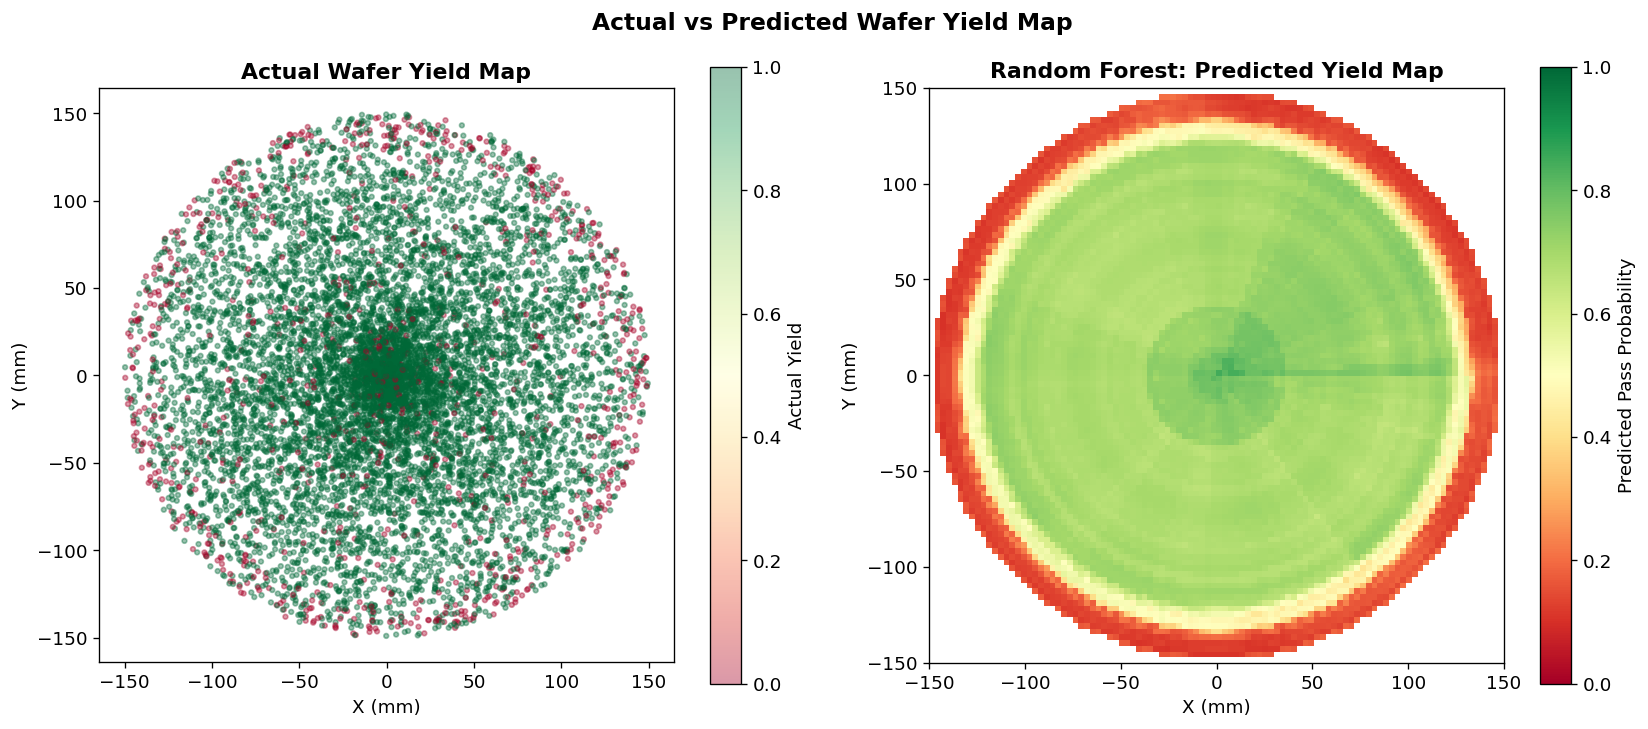

The model has successfully learned the edge yield drop-off pattern.


In [5]:
# Generate a dense grid of points across the wafer
grid_size = 100
x_grid = np.linspace(-150, 150, grid_size)
y_grid = np.linspace(-150, 150, grid_size)
xx, yy = np.meshgrid(x_grid, y_grid)

# Convert to polar features
dist_grid = np.sqrt(xx**2 + yy**2).flatten()
angle_grid = np.degrees(np.arctan2(yy, xx)).flatten() % 360

# Use median values for other features
grid_df = pd.DataFrame({
    'distance_from_center_mm': dist_grid,
    'angle_degrees': angle_grid,
    'etch_gas_flow': df['etch_gas_flow'].median(),
    'spin_coat_rpm': df['spin_coat_rpm'].median(),
    'litho_overlay_error_nm': df['litho_overlay_error_nm'].median()
})

# Mask points outside the wafer
inside_wafer = dist_grid <= 150
pred_proba = np.full(len(dist_grid), np.nan)
pred_proba[inside_wafer] = rf.predict_proba(grid_df[inside_wafer])[:, 1]
pred_grid = pred_proba.reshape(grid_size, grid_size)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual wafer map
ax = axes[0]
sc = ax.scatter(df['x_mm'], df['y_mm'], c=df['yield_pass'],
                cmap='RdYlGn', alpha=0.4, s=8)
plt.colorbar(sc, ax=ax, label='Actual Yield')
ax.set_aspect('equal'); ax.set_title('Actual Wafer Yield Map', fontweight='bold')
ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')

# Predicted yield probability map
ax = axes[1]
im = ax.imshow(pred_grid, extent=[-150, 150, -150, 150], origin='lower',
               cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
plt.colorbar(im, ax=ax, label='Predicted Pass Probability')
ax.set_title('Random Forest: Predicted Yield Map', fontweight='bold')
ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')

plt.suptitle('Actual vs Predicted Wafer Yield Map', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/wafer_predicted_map.png', bbox_inches='tight')
plt.show()
print('The model has successfully learned the edge yield drop-off pattern.')

## 5. Key Takeaways

| Concept | Post-Silicon Application |
|---|---|
| **Non-linear boundaries** | Yield does not drop linearly with distance — it is stable then falls sharply. Trees capture this naturally. |
| **Feature importance** | `distance_from_center_mm` and `litho_overlay_error_nm` dominate. Process engineers know where to focus. |
| **Predicted wafer map** | The model's spatial predictions match the actual yield pattern, validating that it learned the physics. |
| **Actionable insight** | Dies beyond 120mm radius with overlay error > 4nm have the highest predicted failure probability. |

**The engineering value:** A Random Forest trained on historical wafer data can predict the yield of a new wafer *before* the full test suite completes, enabling faster feedback to the process engineering team.